Clustered data saved as kmedian_clustered_customers.csv


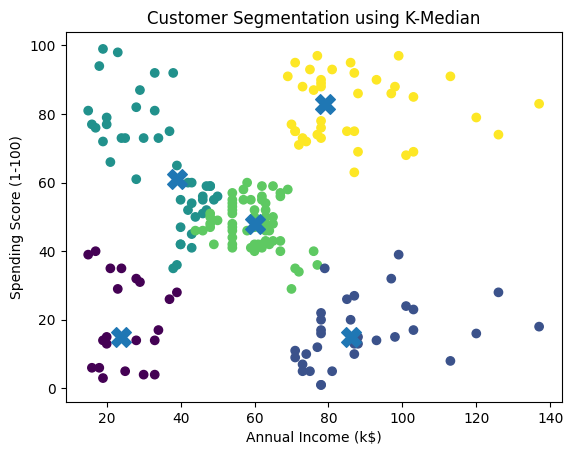

Graph saved as kmedian_cluster_graph.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load Dataset
# ----------------------------
data = pd.read_csv("Mall_Customers.csv")

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values

# ----------------------------
# Parameters
# ----------------------------
k = 5
max_iterations = 100

# Randomly initialize medians
np.random.seed(0)
medians = X[np.random.choice(len(X), k, replace=False)]

# ----------------------------
# K-Median Algorithm
# ----------------------------
for _ in range(max_iterations):

    # Assign clusters
    distances = np.abs(X[:, np.newaxis] - medians).sum(axis=2)
    clusters = np.argmin(distances, axis=1)

    new_medians = []

    for i in range(k):
        cluster_points = X[clusters == i]
        if len(cluster_points) > 0:
            new_median = np.median(cluster_points, axis=0)
        else:
            new_median = medians[i]
        new_medians.append(new_median)

    new_medians = np.array(new_medians)

    if np.all(medians == new_medians):
        break

    medians = new_medians

# ----------------------------
# Add Cluster Column
# ----------------------------
data['Cluster'] = clusters

# ----------------------------
# Save Output Dataset
# ----------------------------
data.to_csv("kmedian_clustered_customers.csv", index=False)

print("Clustered data saved as kmedian_clustered_customers.csv")

# ----------------------------
# Plot Clusters
# ----------------------------
plt.figure()

plt.scatter(X[:,0], X[:,1], c=clusters)

# Plot medians
plt.scatter(medians[:,0], medians[:,1], marker='X', s=200)

plt.title("Customer Segmentation using K-Median")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

# Save graph
plt.savefig("kmedian_cluster_graph.png")

plt.show()

print("Graph saved as kmedian_cluster_graph.png")